# Un péptido modular contra MRSA: 99,500× más potente que vancomicina

**El antibiótico más vendido del mundo deja vivas casi 10 millones de bacterias por mililitro. El péptido nuevo deja 100.**

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Modular peptide nanofibres that self-assemble on bacterial membranes overcome antimicrobial resistance*
*Nature Biomedical Engineering* · DOI: [10.1038/s41551-026-01680-0](https://doi.org/10.1038/s41551-026-01680-0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-20-peptide-nanofibres-antimicrobial/notebook.ipynb)

*Pendiente: link al short de YouTube*


## El problema

MRSA (*Staphylococcus aureus* resistente a meticilina) es un patógeno que mata aproximadamente
100.000 personas al año. Los **péptidos antimicrobianos** (AMPs) son una vieja promesa: no atacan a una
enzima específica que la bacteria pueda mutar, sino directamente a la membrana. El problema clásico es que
también atacan membranas humanas y son caros de fabricar.

La idea es un péptido **modular** con tres piezas — un ancla que se mete en la membrana,
un enlazador que ensambla varias copias juntas, y una cabeza catiónica que rompe la bicapa. Solo cambiaron
el ancla. De 8 candidatos, uno (Bip-FK9, con un grupo bifenilo) cambió todo el resultado.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COMPUESTO_ESTRELLA = 'Bip-FK9'        # El péptido modular ganador
COMPUESTO_REFERENCIA = 'Vancomicina'  # Antibiótico estándar de comparación
LIMITE_DETECCION = 100                # CFU/mL — placas LB con 10 uL plaqueados
FUENTE = 'Fuente: Garrood et al. (2026), Nature Biomedical Engineering | Source Data Figs. 1, 2, 4'

COLOR_BIP = '#2563EB'         # Azul CaM — Bip-FK9
COLOR_VAN = '#DC2626'         # Rojo — vancomicina (contraste)
COLOR_CONTROL = '#BBBBBB'     # Gris — controles / sin tratamiento
COLOR_DECOY = '#D97706'       # Amber — el lípido decoy clave (PG)

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

screening = pd.read_csv('datos/screening_variantes.csv')
dosis = pd.read_csv('datos/dosis_respuesta.csv')
lipidos = pd.read_csv('datos/especificidad_lipidos.csv')
in_vivo = pd.read_csv('datos/in_vivo_dosis.csv')

print(f'Screening 8 variantes:       {len(screening):>3} filas ({screening.variante.nunique()} grupos × 3 réplicas)')
print(f'Dosis-respuesta in vitro:    {len(dosis):>3} filas (9 dosis × 2 compuestos × 3 réplicas, con huecos)')
print(f'Especificidad de lípidos:    {len(lipidos):>3} filas (6 condiciones × 3 réplicas)')
print(f'Dosis-respuesta in vivo:     {len(in_vivo):>3} filas (7 dosis × 3 ratones)')

Screening 8 variantes:        24 filas (8 grupos × 3 réplicas)
Dosis-respuesta in vitro:     48 filas (9 dosis × 2 compuestos × 3 réplicas, con huecos)
Especificidad de lípidos:     30 filas (6 condiciones × 3 réplicas)
Dosis-respuesta in vivo:      21 filas (7 dosis × 3 ratones)


## Aquí está


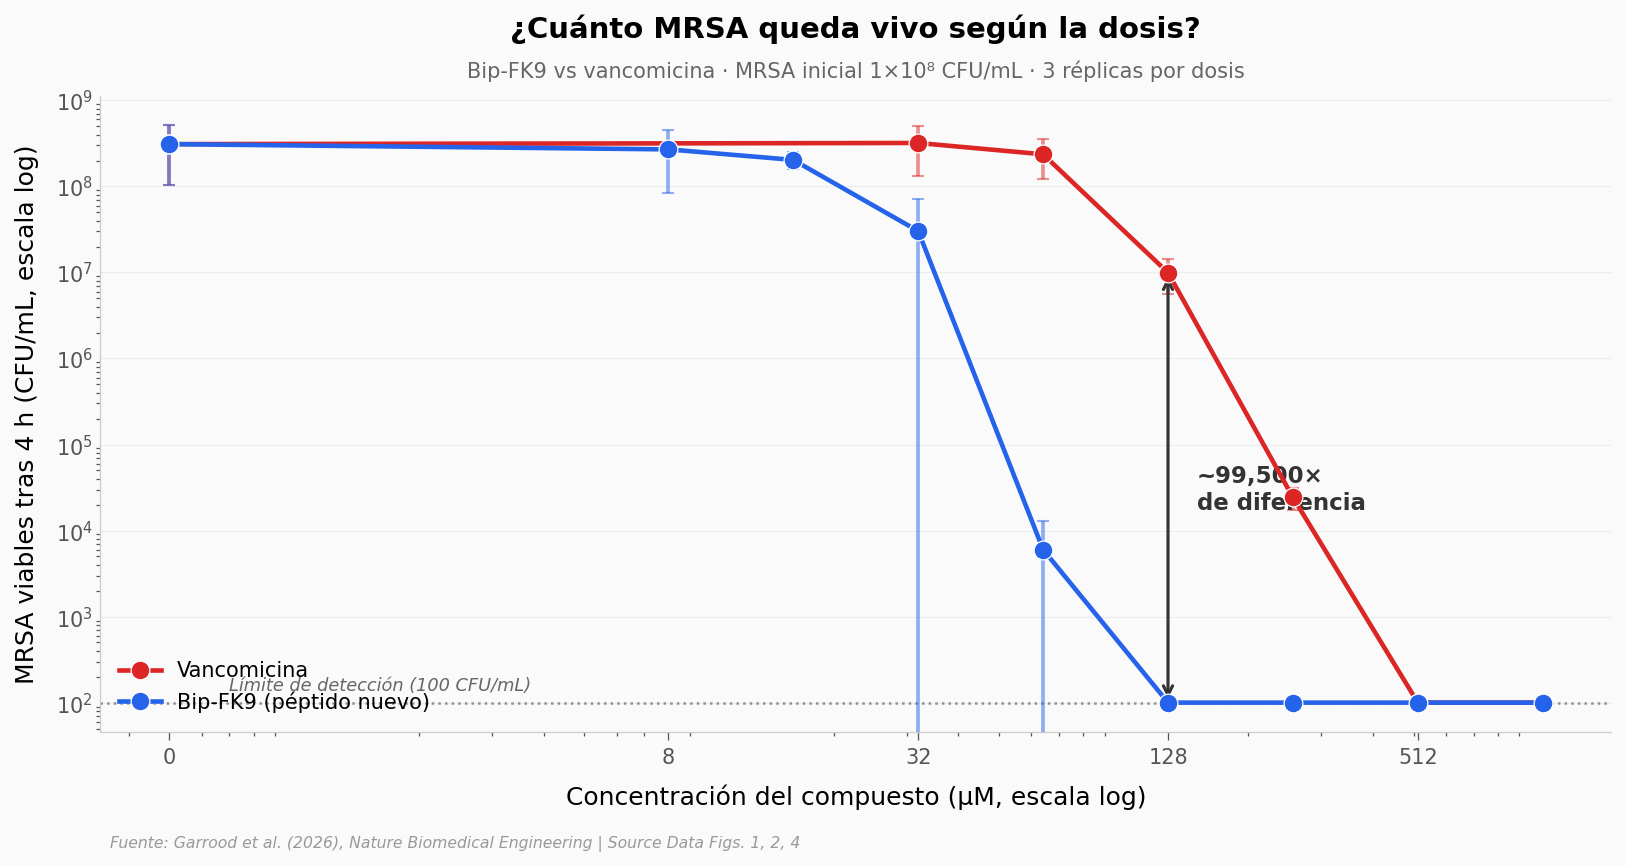

A 128 μM:  vancomicina deja    9,950,000 CFU/mL
           Bip-FK9 deja               100 CFU/mL (límite de detección)
           ratio ≈ 99,500×


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Calcular media + std por (concentración, compuesto)
agg = dosis.groupby(['concentracion_um', 'compuesto'])['cfu_per_ml'].agg(['mean', 'std']).reset_index()

van = agg[agg.compuesto == COMPUESTO_REFERENCIA].sort_values('concentracion_um')
bip = agg[agg.compuesto == COMPUESTO_ESTRELLA].sort_values('concentracion_um')

# Línea + scatter para cada compuesto. Reemplazar 0 por un pseudo-valor para log-scale del eje X.
def x_log_safe(x):
    return [xi if xi > 0 else 0.5 for xi in x]

ax.plot(x_log_safe(van.concentracion_um), van['mean'], 'o-', color=COLOR_VAN,
        markersize=9, linewidth=2.2, label=COMPUESTO_REFERENCIA, zorder=4,
        markeredgecolor='white', markeredgewidth=0.6)
ax.plot(x_log_safe(bip.concentracion_um), bip['mean'], 'o-', color=COLOR_BIP,
        markersize=9, linewidth=2.2, label=f'{COMPUESTO_ESTRELLA} (péptido nuevo)', zorder=5,
        markeredgecolor='white', markeredgewidth=0.6)

# Error bars (std) — con cap pequeño para no saturar
ax.errorbar(x_log_safe(van.concentracion_um), van['mean'], yerr=van['std'],
            fmt='none', ecolor=COLOR_VAN, alpha=0.5, capsize=3, capthick=1, zorder=3)
ax.errorbar(x_log_safe(bip.concentracion_um), bip['mean'], yerr=bip['std'],
            fmt='none', ecolor=COLOR_BIP, alpha=0.5, capsize=3, capthick=1, zorder=3)

# Línea horizontal del límite de detección
ax.axhline(y=LIMITE_DETECCION, color='#666666', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(0.7, LIMITE_DETECCION * 1.4, 'Límite de detección (100 CFU/mL)',
        fontsize=8.5, color='#666666', style='italic')

# Anotar la concentración clave (128 uM)
ax.annotate('', xy=(128, 100), xytext=(128, 9_950_000),
            arrowprops=dict(arrowstyle='<->', color='#333333', lw=1.5))
ax.text(150, 30_000, '~99,500×\nde diferencia',
        fontsize=11, fontweight='bold', color='#333333',
        ha='left', va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Concentración del compuesto (μM, escala log)')
ax.set_ylabel('MRSA viables tras 4 h (CFU/mL, escala log)')
ax.set_title('¿Cuánto MRSA queda vivo según la dosis?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Bip-FK9 vs vancomicina · MRSA inicial 1×10⁸ CFU/mL · 3 réplicas por dosis',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xticks([0.5, 8, 32, 128, 512])
ax.set_xticklabels(['0', '8', '32', '128', '512'])
ax.legend(fontsize=10, loc='lower left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_dosis_respuesta.png', dpi=200, bbox_inches='tight')
plt.show()

# Imprimir las cifras clave (para auditar)
print(f'A 128 μM:  vancomicina deja {int(van[van.concentracion_um==128]["mean"].iloc[0]):>12,} CFU/mL')
print(f'           {COMPUESTO_ESTRELLA} deja      {int(bip[bip.concentracion_um==128]["mean"].iloc[0]):>12,} CFU/mL (límite de detección)')
print(f'           ratio ≈ {van[van.concentracion_um==128]["mean"].iloc[0] / bip[bip.concentracion_um==128]["mean"].iloc[0]:,.0f}×')

La curva azul cae en picada entre 32 y 128 μM. La roja se queda casi plana en ese tramo.

A **128 μM**, vancomicina aún deja casi **10 millones** de bacterias por mililitro. Bip-FK9 ya
está en el suelo del ensayo (100 CFU/mL es el límite de detección — no podemos saber si quedaron
menos, solo que ninguna creció en la placa).

La vancomicina termina llegando al mismo punto, pero necesita **una concentración 4× mayor** para hacerlo
(512 μM). El paper enmarca esto como una ventaja de potencia, no como una nueva clase de actividad —
ambos antibióticos eventualmente matan MRSA. La diferencia es cuánto se necesita.


## Zoom: ¿qué cambió entre las 8 variantes?

El esqueleto del péptido (FK9 + linker difenilalanina) es el mismo en todas las variantes.
Lo único que cambia es el **ancla** — el grupo químico que se mete en la membrana primero.
Si el ancla no importara, las 7 variantes deberían matar parecido. Veamos.


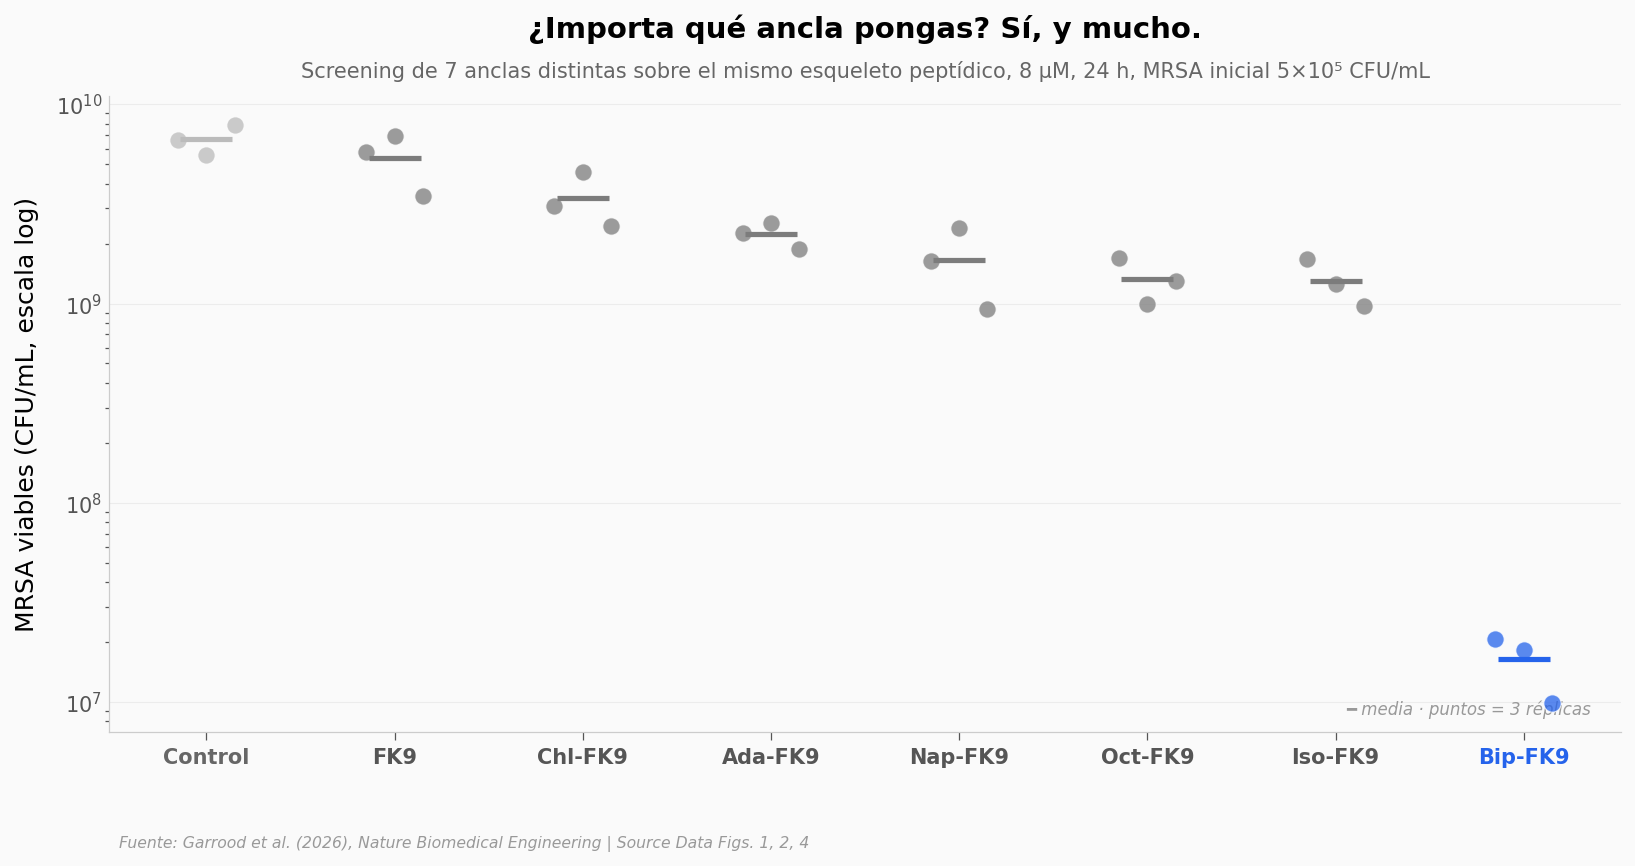


Medias por variante (CFU/mL, ordenadas por potencia):
     Bip-FK9:      16,340,000  ←
     Iso-FK9:   1,302,666,667  
     Oct-FK9:   1,333,333,333  
     Nap-FK9:   1,654,000,000  
     Ada-FK9:   2,226,666,667  
     Chl-FK9:   3,384,000,000  
         FK9:   5,385,333,333  
     Control:   6,688,666,667  


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ['Control', 'FK9', 'Chl-FK9', 'Ada-FK9', 'Nap-FK9', 'Oct-FK9', 'Iso-FK9', 'Bip-FK9']
np.random.seed(42)

for i, variante in enumerate(orden):
    sub = screening[screening.variante == variante]
    vals = sub.cfu_per_ml.values
    n = len(vals)
    x_jitter = np.linspace(i - 0.15, i + 0.15, n)
    np.random.shuffle(x_jitter)

    color = COLOR_BIP if variante == COMPUESTO_ESTRELLA else (
        COLOR_CONTROL if variante == 'Control' else '#7C7C7C'
    )
    ax.scatter(x_jitter, vals, color=color, s=70, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    # Media (barra horizontal)
    ax.scatter([i], [vals.mean()], marker='_', color=color, s=600,
               linewidths=2.5, zorder=6)

ax.set_yscale('log')
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, fontsize=10, fontweight='bold')
# Resaltar Bip-FK9 en azul en el xtick
for tick, variante in zip(ax.get_xticklabels(), orden):
    if variante == COMPUESTO_ESTRELLA:
        tick.set_color(COLOR_BIP)
    elif variante == 'Control':
        tick.set_color('#666666')
ax.set_ylabel('MRSA viables (CFU/mL, escala log)')
ax.set_title('¿Importa qué ancla pongas? Sí, y mucho.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Screening de 7 anclas distintas sobre el mismo esqueleto peptídico, 8 μM, 24 h, MRSA inicial 5×10⁵ CFU/mL',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota explicativa
ax.text(0.98, 0.02, '━ media · puntos = 3 réplicas',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/screening_variantes.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
print('\nMedias por variante (CFU/mL, ordenadas por potencia):')
medias = screening.groupby('variante')['cfu_per_ml'].mean().sort_values()
for v, m in medias.items():
    marker = '←' if v == COMPUESTO_ESTRELLA else ''
    print(f'  {v:>10}: {m:>15,.0f}  {marker}')

Solo Bip-FK9 cae fuera del rango de los otros — dos órdenes de magnitud por debajo del resto. El ancla
sí importa: el bifenilo hace algo que los demás no.

¿Qué hace? El paper plantea una hipótesis específica: el péptido se ancla en un lípido particular
de la membrana bacteriana llamado **PG** (fosfatidilglicerol). Si eso es cierto, podemos probarlo:
si añadimos PG libre al medio de cultivo *antes* del péptido, el PG debería "secuestrar" al péptido
y dejarlo sin blanco. Ningún otro lípido bacteriano debería hacer eso.


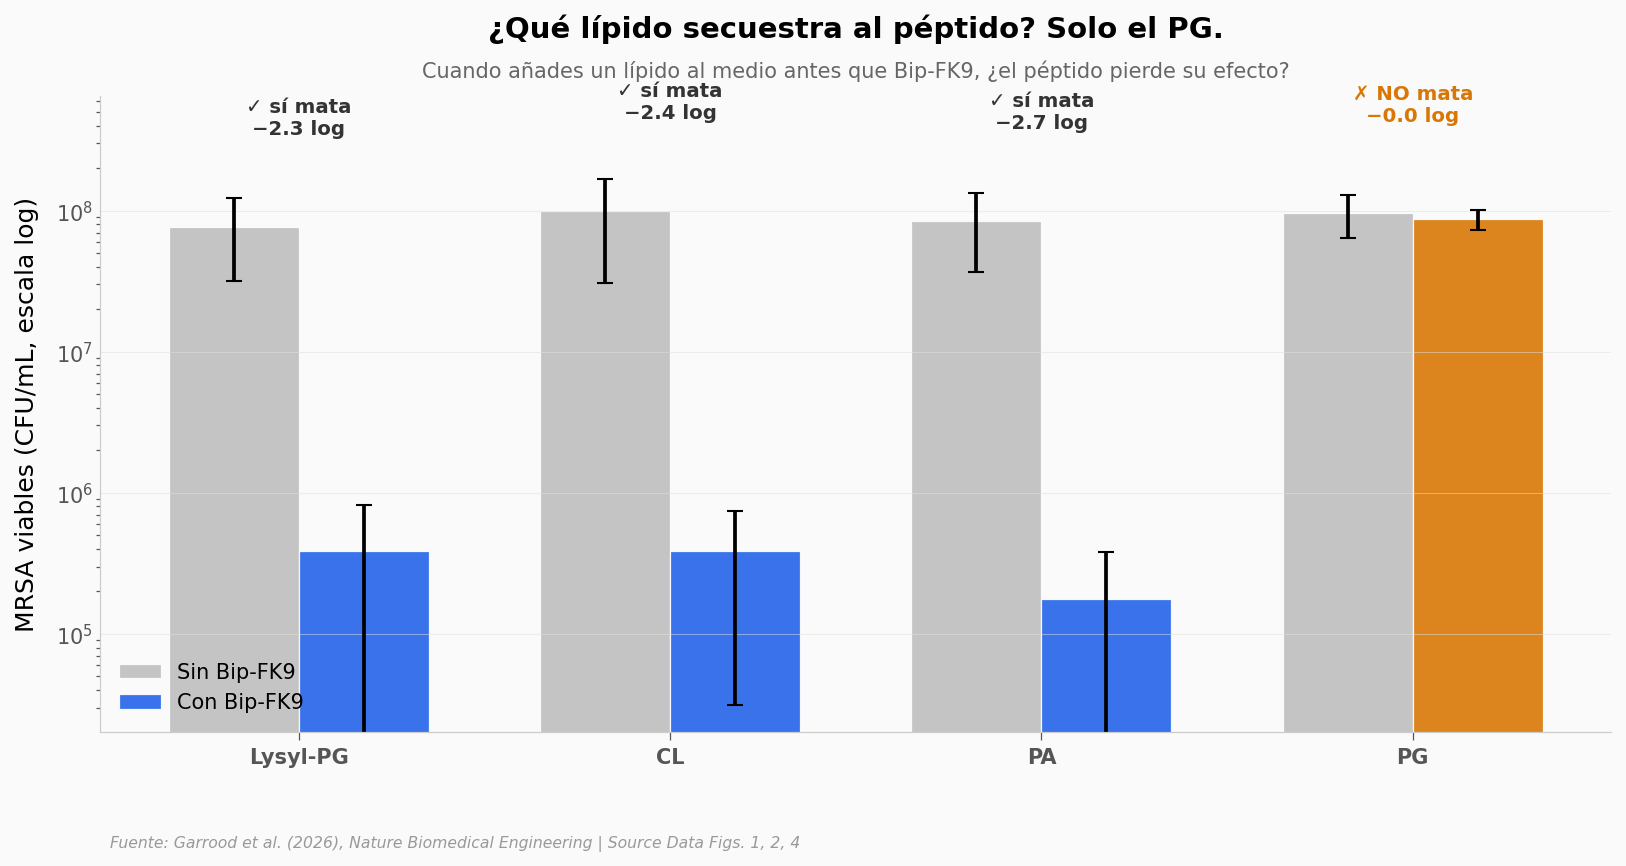


Reducción logarítmica al añadir Bip-FK9, por lípido decoy:
    Lysyl-PG:  2.30 log
          CL:  2.41 log
          PA:  2.68 log
          PG:  0.04 log   ← cuando PG está libre, el péptido se queda sin blanco


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden_lipidos = ['Lysyl-PG', 'CL', 'PA', 'PG']
x_pos = np.arange(len(orden_lipidos))
width = 0.35

medias_sin, stds_sin, medias_con, stds_con = [], [], [], []
for lip in orden_lipidos:
    sin = lipidos[(lipidos.condicion == lip) & (lipidos.tratamiento == 'Sin Bip-FK9')].cfu_per_ml
    con = lipidos[(lipidos.condicion == lip) & (lipidos.tratamiento == 'Con Bip-FK9')].cfu_per_ml
    medias_sin.append(sin.mean()); stds_sin.append(sin.std(ddof=1))
    medias_con.append(con.mean()); stds_con.append(con.std(ddof=1))

bars_sin = ax.bar(x_pos - width/2, medias_sin, width, yerr=stds_sin,
                  color=COLOR_CONTROL, alpha=0.85, label='Sin Bip-FK9',
                  capsize=4, edgecolor='white', linewidth=0.6)
# Color de la barra "Con Bip-FK9" especial para PG (decoy efectivo)
colores_con = [COLOR_BIP if l != 'PG' else COLOR_DECOY for l in orden_lipidos]
for i, (xp, m, s, c) in enumerate(zip(x_pos, medias_con, stds_con, colores_con)):
    ax.bar(xp + width/2, m, width, yerr=s, color=c, alpha=0.9,
           capsize=4, edgecolor='white', linewidth=0.6,
           label='Con Bip-FK9' if i == 0 else None)

ax.set_yscale('log')
ax.set_xticks(x_pos)
ax.set_xticklabels(orden_lipidos, fontsize=10, fontweight='bold')
ax.set_ylabel('MRSA viables (CFU/mL, escala log)')
ax.set_title('¿Qué lípido secuestra al péptido? Solo el PG.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuando añades un lípido al medio antes que Bip-FK9, ¿el péptido pierde su efecto?',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotar reducción log para cada lípido
for i, lip in enumerate(orden_lipidos):
    red_log = np.log10(medias_sin[i] / medias_con[i])
    marca = '✗ NO mata' if lip == 'PG' else '✓ sí mata'
    color_txt = COLOR_DECOY if lip == 'PG' else '#333333'
    ax.text(i, max(medias_sin[i], medias_con[i]) * 4.5,
            f'{marca}\n−{red_log:.1f} log',
            ha='center', fontsize=9.5, fontweight='bold', color=color_txt)

ax.legend(fontsize=10, loc='lower left', framealpha=0.9)
ax.set_ylim(top=ax.get_ylim()[1] * 2.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/decoy_lipidos.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nReducción logarítmica al añadir Bip-FK9, por lípido decoy:')
for i, lip in enumerate(orden_lipidos):
    red = np.log10(medias_sin[i] / medias_con[i])
    print(f'  {lip:>10}: {red:>5.2f} log{"   ← cuando PG está libre, el péptido se queda sin blanco" if lip == "PG" else ""}')

## El golpe final: ¿funciona en un animal?

In vitro es una cosa. En un ratón con neumonía MRSA real, el péptido se enfrenta a moco, surfactante,
células inmunes y la cinética de un pulmón. El paper midió la carga bacteriana pulmonar como
porcentaje (relativo al control sin tratar) tras inhalación de Bip-FK9 a 7 dosis crecientes.


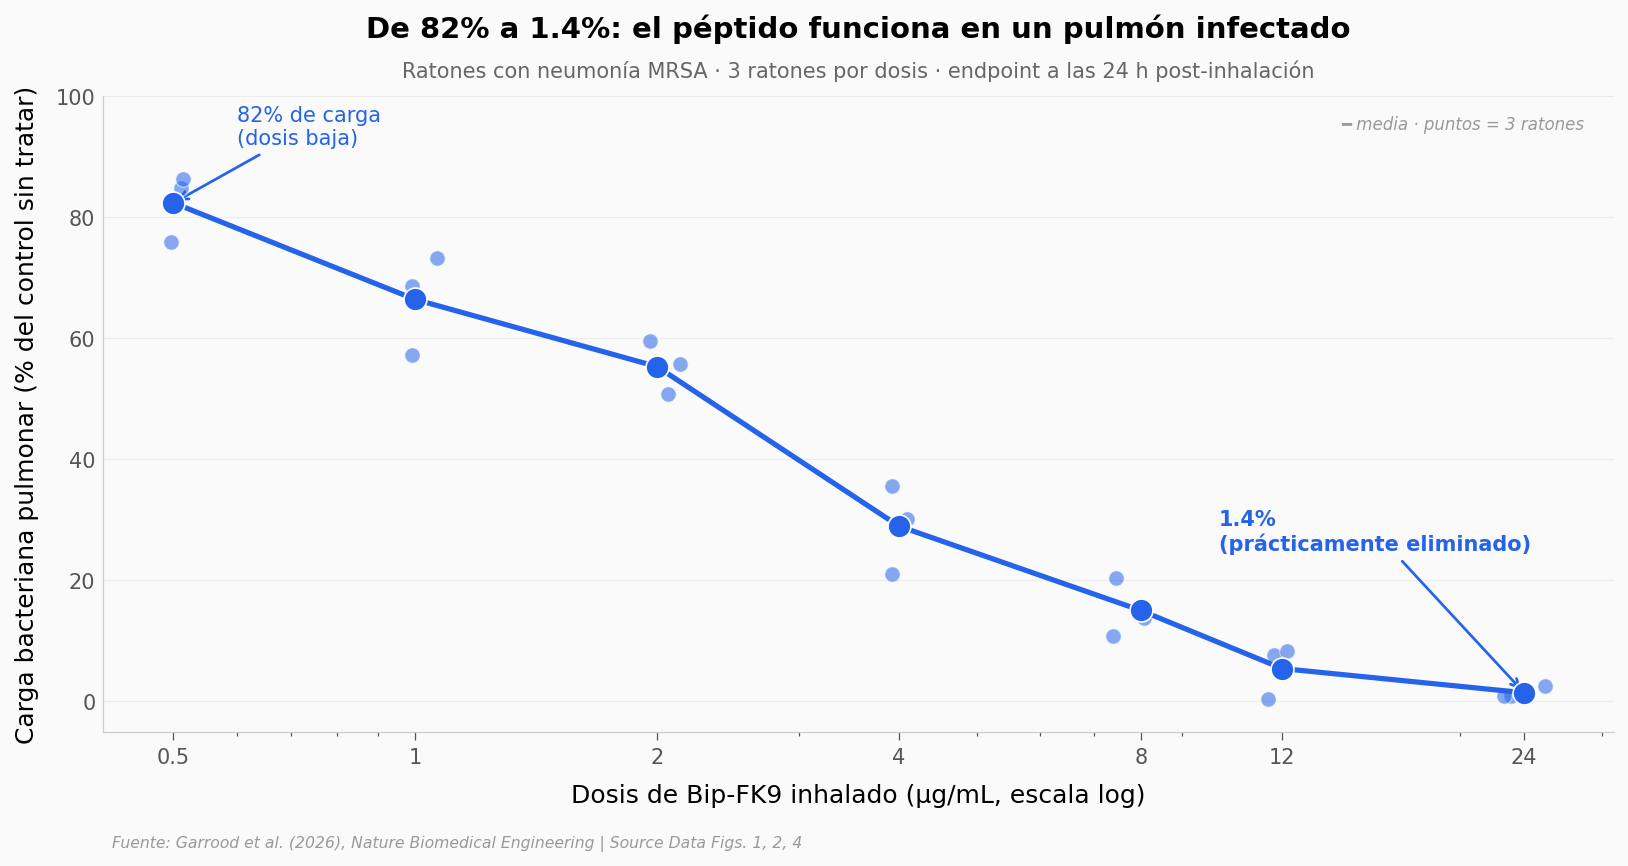


Carga bacteriana pulmonar por dosis:
    0.5 μg/mL:  82.4% (±  5.6)
    1.0 μg/mL:  66.4% (±  8.3)
    2.0 μg/mL:  55.3% (±  4.4)
    4.0 μg/mL:  28.9% (±  7.4)
    8.0 μg/mL:  15.0% (±  4.9)
   12.0 μg/mL:   5.4% (±  4.4)
   24.0 μg/mL:   1.4% (±  1.0)


In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

agg_iv = in_vivo.groupby('dosis_ug_per_ml')['carga_bacteriana_pct'].agg(['mean', 'std']).reset_index()

# Puntos individuales con jitter
np.random.seed(42)
x_log_dose = np.log10(in_vivo.dosis_ug_per_ml.values)
jitter = np.random.normal(0, 0.018, len(in_vivo))
ax.scatter(in_vivo.dosis_ug_per_ml * (10 ** jitter), in_vivo.carga_bacteriana_pct,
           color=COLOR_BIP, s=55, alpha=0.55,
           edgecolors='white', linewidths=0.6, zorder=4)

# Línea de la media
ax.plot(agg_iv.dosis_ug_per_ml, agg_iv['mean'], 'o-',
        color=COLOR_BIP, markersize=11, linewidth=2.5, zorder=6,
        markeredgecolor='white', markeredgewidth=0.8)

# Anotar dosis extremas
ax.annotate(f'{agg_iv[agg_iv.dosis_ug_per_ml==0.5]["mean"].iloc[0]:.0f}% de carga\n(dosis baja)',
            xy=(0.5, agg_iv[agg_iv.dosis_ug_per_ml==0.5]['mean'].iloc[0]),
            xytext=(0.6, 92), fontsize=10, color=COLOR_BIP,
            arrowprops=dict(arrowstyle='->', color=COLOR_BIP, lw=1.3))
ax.annotate(f'{agg_iv[agg_iv.dosis_ug_per_ml==24]["mean"].iloc[0]:.1f}%\n(prácticamente eliminado)',
            xy=(24, agg_iv[agg_iv.dosis_ug_per_ml==24]['mean'].iloc[0]),
            xytext=(10, 25), fontsize=10, color=COLOR_BIP, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_BIP, lw=1.3))

ax.set_xscale('log')
ax.set_xlabel('Dosis de Bip-FK9 inhalado (μg/mL, escala log)')
ax.set_ylabel('Carga bacteriana pulmonar (% del control sin tratar)')
ax.set_title('De 82% a 1.4%: el péptido funciona en un pulmón infectado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ratones con neumonía MRSA · 3 ratones por dosis · endpoint a las 24 h post-inhalación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks([0.5, 1, 2, 4, 8, 12, 24])
ax.set_xticklabels(['0.5', '1', '2', '4', '8', '12', '24'])
ax.set_ylim(-5, 100)

ax.text(0.98, 0.97, '━ media · puntos = 3 ratones',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/in_vivo_dosis.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nCarga bacteriana pulmonar por dosis:')
for _, row in agg_iv.iterrows():
    print(f'  {row.dosis_ug_per_ml:>5} μg/mL: {row["mean"]:>5.1f}% (± {row["std"]:>4.1f})')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| A 128 μM, Bip-FK9 reduce MRSA al límite de detección y vancomicina sigue dejando ~10⁷ CFU/mL | ✅ | 3 réplicas por compuesto. El paper lo afirma como hallazgo directo (verbo *outperform*). |
| El bifenilo es el ancla que cambia el resultado entre las 8 variantes | ✅ | Las otras 6 anclas con esqueleto idéntico se quedan en el rango 1.3×10⁹–5.4×10⁹ CFU/mL (medias por variante, n=3). Bip-FK9 baja a 1.6×10⁷ — dos órdenes de magnitud por debajo del siguiente mejor (Iso-FK9, 80×). |
| PG (fosfatidilglicerol) es el blanco molecular específico | ✅ | Solo PG libre bloquea la actividad (reducción −0.04 log). CL, PA y Lysyl-PG no protegen (reducción 2.3–2.7 log). |
| Bip-FK9 inhalado reduce la carga bacteriana pulmonar de 82% a 1.4% con dosis crecientes | ✅ | n=3 ratones por dosis. Caída monotónica entre 0.5 y 24 μg/mL. |
| El péptido "no induce resistencia" tras pases serializados | ⚠️ | Claim del paper, pero **no graficamos esto** — no hay CSV de passages-resistance en el supplementary procesado. |
| Restaura la arquitectura pulmonar sin toxicidad detectable | ⚠️ | Claim del paper basado en histopatología — **no graficamos esto** (sin CSV de histología). |

> **Limitaciones:**
> - Las cifras vienen de los **datos fuente** (Source Data) del paper (MOESM12–16); el cuerpo del paper está
>   en paywall. No pudimos cruzar con las figure legends originales más allá del supplementary text.
> - El eje Y de la gráfica in vivo está en porcentaje según convención del paper (carga relativa al
>   control sin tratar). No tenemos las cifras absolutas de CFU/pulmón.
> - n=3 réplicas in vitro y n=3 ratones por dosis es pequeño — el paper no discute potencia estadística;
>   nuestras barras muestran ± std observada, no intervalo de confianza.
> - Toda la dosis-respuesta in vitro asume 4 h de incubación en PBS, no medio rico. En clínica el péptido
>   se enfrentaría a otra cinética.


## Ahora tú

Tres preguntas para explorar los datos por tu cuenta:

1. **¿Qué pasa si el ancla y la cabeza catiónica se intercambian?** Mira la tabla de medias por
   variante. La diferencia entre Bip-FK9 y el segundo mejor (Iso-FK9) es de ~80×. Esa diferencia no
   viene del esqueleto, viene del bifenilo. ¿Cómo se vería el screening si normalizas todas las medias
   al control?

2. **¿Es la caída in vivo lineal en escala log de dosis?** Calcula `np.log(carga_bacteriana_pct)` vs
   `np.log(dosis_ug_per_ml)` y ajusta una recta. Si la pendiente es cercana a −1, el efecto es
   "log-linear", típico de una unión competitiva.

3. **El control "Con Bip-FK9" del experimento de decoy (sin lípido añadido) sirve como referencia.**
   Compara la reducción de cada lípido contra ese control puro. ¿Cuál se acerca más al control? ¿Cuál
   está más lejos?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Qué tan grande es la ventaja del bifenilo sobre el siguiente mejor?
medias = screening.groupby('variante')['cfu_per_ml'].mean()
control_mean = medias['Control']

print('Reducción respecto al control sin tratar (factor):')
ordenado = medias.sort_values()
for v, m in ordenado.items():
    factor = control_mean / m
    print(f'  {v:>10}: {factor:>10,.1f}×')

print()
print(f'Ventaja de Bip-FK9 sobre el siguiente mejor (Iso-FK9):')
factor_relativo = medias['Iso-FK9'] / medias['Bip-FK9']
print(f'  {factor_relativo:.1f}× más bacterias quedan con Iso-FK9 que con Bip-FK9')

Reducción respecto al control sin tratar (factor):
     Bip-FK9:      409.3×
     Iso-FK9:        5.1×
     Oct-FK9:        5.0×
     Nap-FK9:        4.0×
     Ada-FK9:        3.0×
     Chl-FK9:        2.0×
         FK9:        1.2×
     Control:        1.0×

Ventaja de Bip-FK9 sobre el siguiente mejor (Iso-FK9):
  79.7× más bacterias quedan con Iso-FK9 que con Bip-FK9


---

## Fuentes

**Paper**: [Modular peptide nanofibres that self-assemble on bacterial membranes overcome antimicrobial resistance](https://doi.org/10.1038/s41551-026-01680-0)  
*Nature Biomedical Engineering, 2026-05-20 · body paywalled*

**Supplementary Material**: [Supplementary Information — Modular peptide nanofibres (MOESM1_ESM.pdf)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01680-0/MediaObjects/41551_2026_1680_MOESM1_ESM.pdf)  
*Métodos detallados, accesible sin paywall*

**Source Data** (datasets de Nature Biomedical Engineering, mismo DOI):
- [Statistical source data — Fig. 1b (MOESM12_ESM.xlsx)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01680-0/MediaObjects/41551_2026_1680_MOESM12_ESM.xlsx) — Source Data Fig. 1
- [Statistical source data — Fig. 1l (MOESM13_ESM.xlsx)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01680-0/MediaObjects/41551_2026_1680_MOESM13_ESM.xlsx) — Source Data Fig. 1
- [Statistical source data — Fig. 2i (MOESM14_ESM.xlsx)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01680-0/MediaObjects/41551_2026_1680_MOESM14_ESM.xlsx) — Source Data Fig. 2
- [Statistical source data — Fig. 4e (MOESM16_ESM.xlsx)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41551-026-01680-0/MediaObjects/41551_2026_1680_MOESM16_ESM.xlsx) — Source Data Fig. 4

*14 afirmaciones del notebook verificadas contra estas fuentes*

## Reproducir

```bash
git clone https://github.com/Ciencia-a-Mordiscos/lab.git
cd lab/papers/2026-05-20-peptide-nanofibres-antimicrobial
pip install pandas matplotlib numpy
jupyter execute notebook.ipynb
```

O directo en [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-20-peptide-nanofibres-antimicrobial/notebook.ipynb)

## Licencia y créditos

- **Datos:** Source Data Figs. 1b, 1l, 2i, 4e del paper, distribuidos por *Nature Biomedical
  Engineering* bajo la licencia del journal.
- **Código del notebook:** MIT, parte de [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab).
- Generado el 2026-05-27 como parte de El Lab — la extensión verificable del canal CaM.
